# R Programming: Palmer Penguins Data Analysis
---

**Author**: DataAngel10  

**Date:** 20-06-2025

---

# 📊 Project Overview

In this project I explored the Palmer Penguins dataset, which is included in the R package and gives body measurements information from three penguin species (Adélie, Chinstrap, and Gentoo). My main goal was to analyze the relationshipr between physical features, such as flipper length and body mass. In order to do this, I used R programing techniques such as data cleaning, exploratory data analysis, visualization and statistical testing. 

## Variables I used in this project:                        
- Species       : Categorical (Adélie, Chinstrap, Gentoo).                    
- Sex           : Categorical (male, female).                                
- Flipper Length: Numeric (flipper length in millimeters).                 
- Body Mass     : Numeric (penguin body mass in grams).

## Technologies I Used:
- R (tidyverse, rstatix, ggplts).
- Jupyter Notebook.

# ✅ Install packages and libraries

In [1]:
if (!require(tidyverse)) install.packages("tidyverse") 
if (!require(palmerpenguins)) install.packages("palmerpenguins")
if (!require(rstatix)) install.packages("rstatix")

# For data manipulation and visualization 
library(tidyverse)

# Loads the palmerpenguins dataset
library(palmerpenguins)

# For statistical tests
library(rstatix)

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: palmerpenguins

Loading required package: rstatix


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




# ✅ Understanding Data 

In [2]:
# Quick check dataset structure 
glimpse(penguins)

Rows: 344
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, …
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, …
$ flipper_length_mm <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186…
$ body_mass_g       <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, …
$ sex               <fct> male, female, female, NA, female, male, female, male…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


In [3]:
# Summary statistics of all variables
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NA's   :2         NA's   :2                  

In [4]:
# Count missing values per column
colSums(is.na(penguins))

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

In [5]:
# Preview first 10 rows
head(penguins, 10)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,34.1,18.1,193,3475,NA,2007


In [6]:
# Check unique values in categorical columns to spot typos or inconsistencies
unique_species <- unique(penguins$species)
print("Unique species values:")
print(unique_species)

unique_island <- unique(penguins$island)
print("Unique island values:")
print(unique_island)

unique_sex <- unique(penguins$sex)
print("Unique sex values:")
print(unique_sex)


[1] "Unique species values:"
[1] Adelie    Gentoo    Chinstrap
Levels: Adelie Chinstrap Gentoo
[1] "Unique island values:"
[1] Torgersen Biscoe    Dream    
Levels: Biscoe Dream Torgersen
[1] "Unique sex values:"
[1] male   female <NA>  
Levels: female male


# ✅ Data Cleaning 

In [7]:
# Remove missing values
penguins_clean <- penguins %>%
  drop_na(species, island, bill_length_mm, bill_depth_mm, flipper_length_mm,body_mass_g, sex)

# Print
penguins_clean

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,41.1,17.6,182,3200,female,2007
Adelie,Torgersen,38.6,21.2,191,3800,male,2007


### Justification for removing missing data:
- The penguin dataset contains few missing values: 11 in the sex variable and 2 in the numerical variables (body mass, flipper length, bill depth and bill length). Since the amount of missing data is very small compared to the full dataset, removing these rows will not significantly reduce the sample size and will help minimize bias in the analysis.


In [8]:
# Verify the cleaning step by checking missing values again
colSums(is.na(penguins_clean))

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 0                 0 
flipper_length_mm       body_mass_g               sex              year 
                0                 0                 0                 0

In [9]:
# Checking structure of the new dataset
glimpse(penguins_clean)

Rows: 333
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, 36.7, 39.3, 38.9, 39.2, 41.1, 38.6…
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, 19.3, 20.6, 17.8, 19.6, 17.6, 21.2…
$ flipper_length_mm <int> 181, 186, 195, 193, 190, 181, 195, 182, 191, 198, 18…
$ body_mass_g       <int> 3750, 3800, 3250, 3450, 3650, 3625, 4675, 3200, 3800…
$ sex               <fct> male, female, female, female, male, female, male, fe…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


In [10]:
# Check for duplicate rows
total_duplicates <- nrow(penguins_clean) - nrow(distinct(penguins_clean))
print(paste("Number of duplicate rows:", total_duplicates))

[1] "Number of duplicate rows: 0"


In [11]:
# Overview cleaned data
head(penguins_clean, 10)
tail(penguins_clean, 10)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,41.1,17.6,182,3200,female,2007
Adelie,Torgersen,38.6,21.2,191,3800,male,2007


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Chinstrap,Dream,50.2,18.8,202,3800,male,2009
Chinstrap,Dream,45.6,19.4,194,3525,female,2009
Chinstrap,Dream,51.9,19.5,206,3950,male,2009
Chinstrap,Dream,46.8,16.5,189,3650,female,2009
Chinstrap,Dream,45.7,17.0,195,3650,female,2009
Chinstrap,Dream,55.8,19.8,207,4000,male,2009
Chinstrap,Dream,43.5,18.1,202,3400,female,2009
Chinstrap,Dream,49.6,18.2,193,3775,male,2009
Chinstrap,Dream,50.8,19.0,210,4100,male,2009


# ✅ Exploratory Data Analysis (EDA)

## Pie Chart: Sex distribution (%) across penguin species.

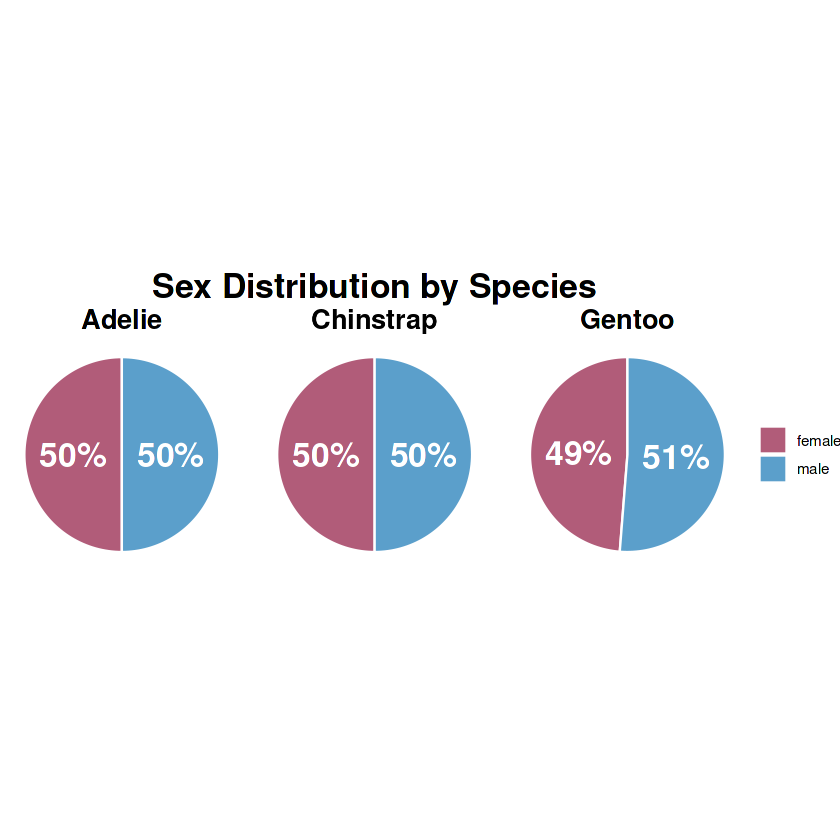

In [12]:
# Count occurrences of each group (species & sex)
penguins_clean %>%
  count(species, sex) %>%

# Calculate percentage and create labels per species
  group_by(species) %>%
  mutate(percentage = n / sum(n),
         label = scales::percent(percentage, accuracy = 1)) %>%

# Set up the plot with ggplot
  ggplot(aes(x = "", y = percentage, fill = sex)) +

# Creates vertical bars  
  geom_col(width = 1, color = "white") +

# Add percentage text labels inside the pie slices
  geom_text(aes(label = label),
            position = position_stack(vjust = 0.5),
            color = "white",
            size = 7 ,
            fontface = "bold") +

# Convert bar chart into pie chart
  coord_polar(theta = "y") +

# Personalize color manually
  scale_fill_manual(values = c("female" = "#B15C79", 
                               "male" = "#5B9FCB")) + 

# Create separate pie charts per species
  facet_wrap(~species) +

# Add title and remove default background
  labs(title = "Sex Distribution by Species") +
  theme_void() +

#Adjust theme elements
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
    legend.position = "right",
    legend.title = element_blank(),
    strip.text = element_text(size = 16, face = "bold")
  ) 

### Observations:
- The pie charts show that sex distribution is nearly even across all species. 


## Outlier detection

### Visual outlier detection with Boxplots: Body mass by sex and species with Jitter.

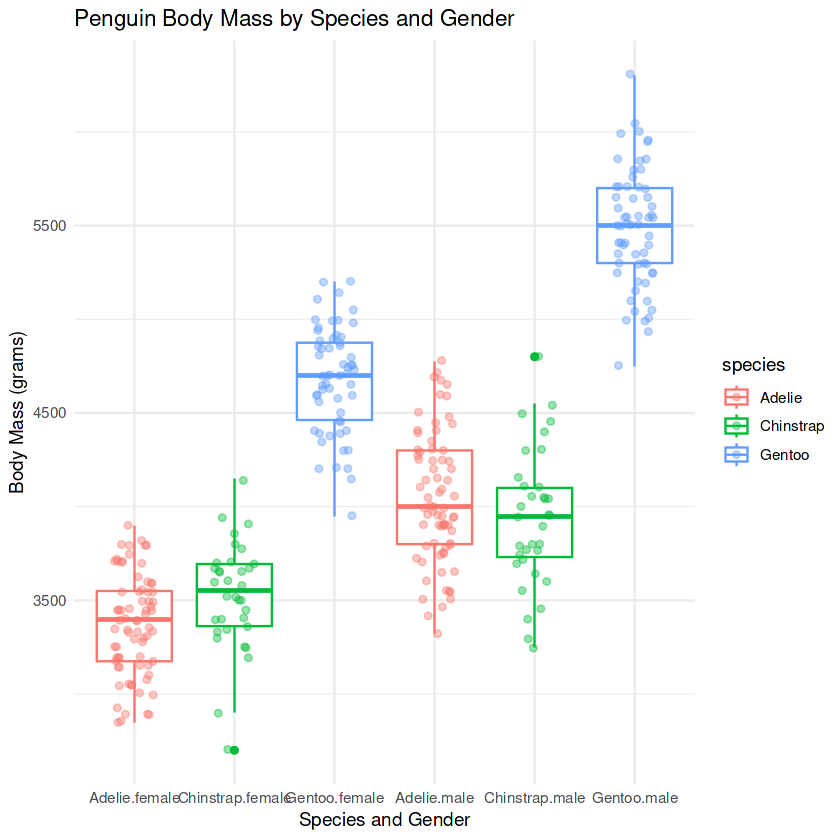

In [13]:
# Create the plot and add variables
ggplot(penguins_clean, aes(x = interaction(species, sex), y = body_mass_g, color = species)) +

# Add the boxplots
  geom_boxplot() + 

# Add individual data points (jitter)
  geom_jitter(width = 0.2, alpha = 0.4) +

# Label the plot
  labs(
    title = "Penguin Body Mass by Species and Gender",
    x = "Species and Gender",
    y = "Body Mass (grams)"
  ) +

# # Apply a clean theme
  theme_minimal()

### Observations:
- The boxplot with jitter shows that males tend to have higher body mass compared to females within each species. Furthermore, it highlights a few apparent outliers within especially in the Chinstrap groups of females and males. However, they appear to fall within the natural variability of the penguin population.



### Visual outlier detection with Boxplot: Flipper length by sex and species with Jitter.

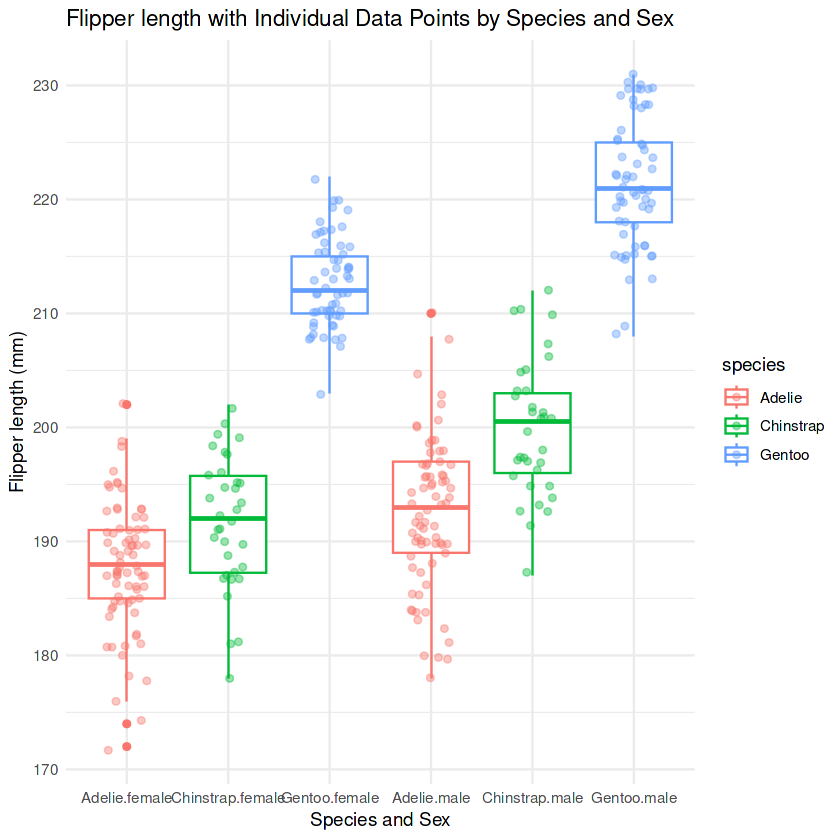

In [14]:
# Create the plot and add variables
ggplot(penguins_clean, aes(x = interaction(species, sex), y = flipper_length_mm, color = species)) +

# Add the boxplots
  geom_boxplot() + 

# Add individual data points (jitter)
  geom_jitter(width = 0.2, alpha = 0.4) +

# # Label the plot
  labs(
    title = "Flipper length with Individual Data Points by Species and Sex",
    x = "Species and Sex",
    y = "Flipper length (mm)"
  ) +

# Apply a clean theme
  theme_minimal()
 

### Observations:
- The Boxplot chart shows that males have longer flipper length that females within the the same species, while by species it shows that Gentoo has the largest flipper length from species, followed by Chinstrap and Adelie. Some slight outliers are seen in all groups, but they seems to be part of the natural variation. 

### Statistical identification of outliers in body mass by sex and species.

In [15]:
# Dataset
penguins_clean %>%

# Group data by species and sex
group_by(species, sex) %>%

# Identify outliers in body mass
  identify_outliers(body_mass_g) %>%

# Keep only rows flagged as outliers or extreme outliers
  filter(is.extreme | is.outlier) %>% 

# Show only outliers or extreme outliers
  select(species, sex, body_mass_g, is.outlier, is.extreme)

species,sex,body_mass_g,is.outlier,is.extreme
<fct>,<fct>,<int>,<lgl>,<lgl>
Chinstrap,female,2700,TRUE,FALSE
Chinstrap,male,4800,TRUE,FALSE


### Observations:
- The Chinstrap group shows two outliers in body mass, 1 in female and 1 in male. Neither appears to be extreme, so they will be kept in the dataset as they likely represent natural variation within the population.


### Statistical identification of outliers in flipper length by sex and species.

In [16]:
# Dataset
penguins_clean %>%

# Group data by species and sex
  group_by(species, sex) %>%

# Identify outliers in flipper length
  identify_outliers(flipper_length_mm) %>%

# Keep only rows flagged as outliers or extreme outliers
  filter(is.extreme | is.outlier) %>%  

# Show only outliers or extreme outliers
  select(species, sex, flipper_length_mm, is.outlier, is.extreme)

species,sex,flipper_length_mm,is.outlier,is.extreme
<fct>,<fct>,<int>,<lgl>,<lgl>
Adelie,female,174,TRUE,FALSE
Adelie,female,172,TRUE,FALSE
Adelie,female,202,TRUE,FALSE
Adelie,male,210,TRUE,FALSE


#### Observations:
- The Adelie group shows four outliers in flipper length with 3 of them being in females and 1 in males. Neither appears to be extreme, so they will be kept in the dataset as they likely represent natural variation within the population.

## Visual exploration of relationship between flipper length and body mass

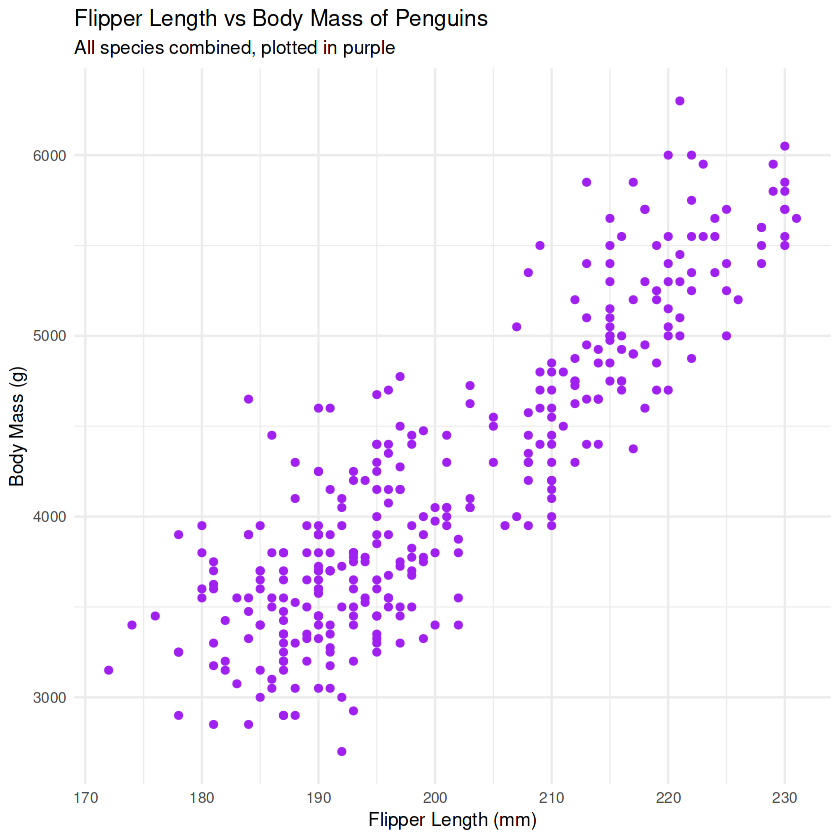

In [17]:
# Set up the plot
ggplot(data = penguins_clean, aes(x = flipper_length_mm, y = body_mass_g)) +

# Add scatter plot points
  geom_point(color = "purple") +

# Labelling the plot
  labs(
    title = "Flipper Length vs Body Mass of Penguins",
    subtitle = "All species combined, plotted in purple",
    x = "Flipper Length (mm)",
    y = "Body Mass (g)"
  ) +

# Use a clean theme
  theme_minimal()

### Scatter plot: Shape encoding by species.

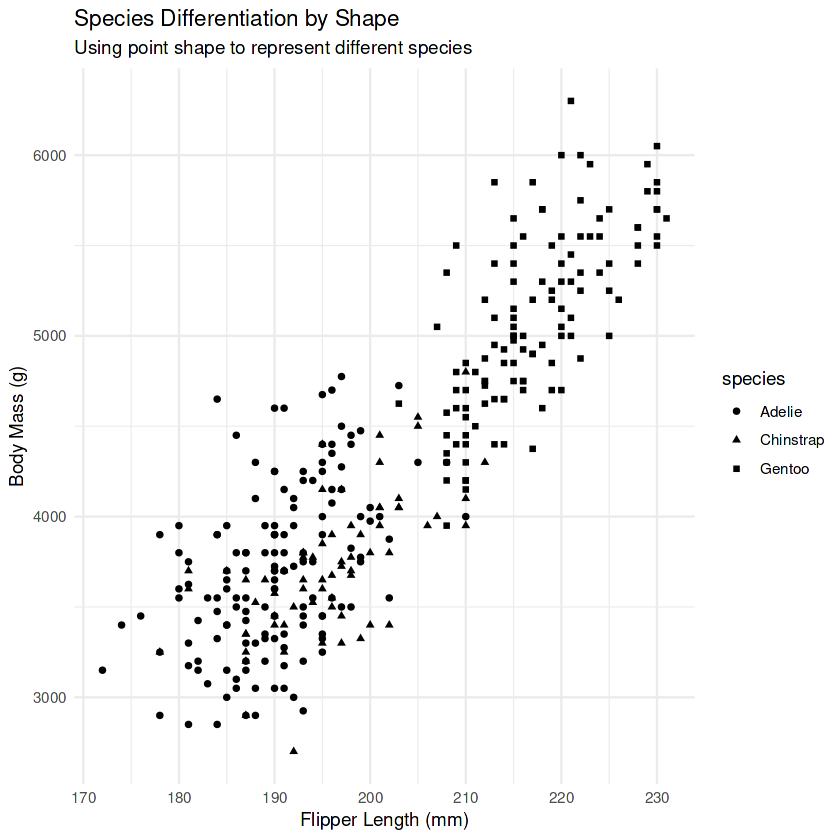

In [18]:
# Set up the base plot
ggplot(penguins_clean, aes(x = flipper_length_mm, y = body_mass_g)) +

# Add scatter plot points with shape by species
  geom_point(aes(shape = species)) +

# Add labels and titles
  labs(
    title = "Species Differentiation by Shape",
    subtitle = "Using point shape to represent different species",
    x = "Flipper Length (mm)",
    y = "Body Mass (g)"
  ) +

# Apply a clean theme
  theme_minimal()


### Scatter plot: color and  shape by species, faceted by sex

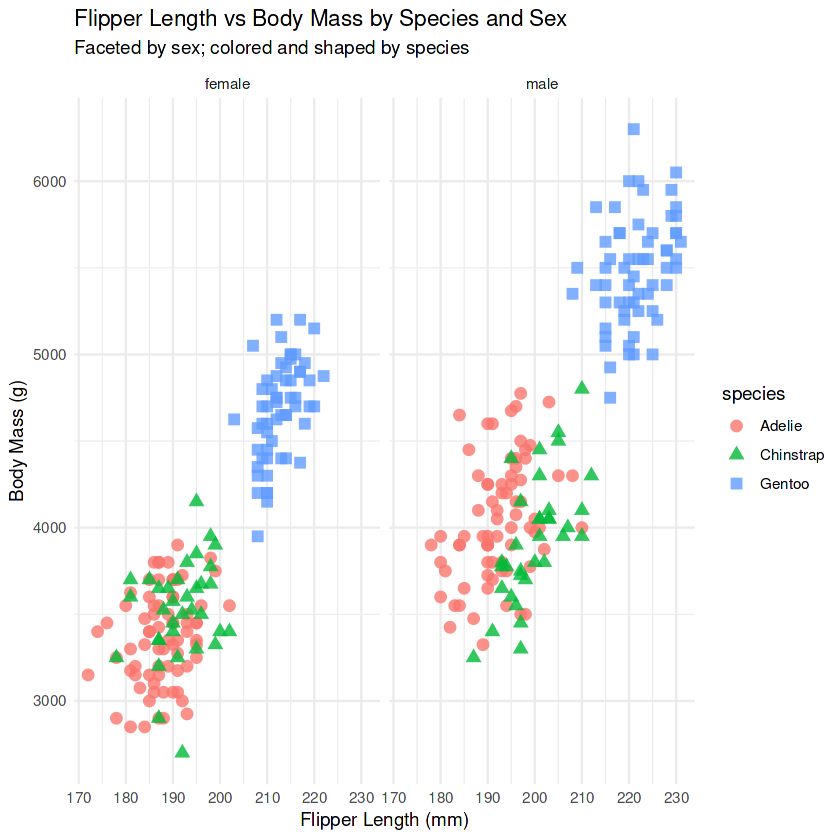

In [19]:

# Create a scatter plot using the cleaned penguin dataset
ggplot(penguins_clean, aes(
    x = flipper_length_mm,     
    y = body_mass_g)) +       

# Add data points to the plot
  geom_point(aes(
      color = species,         
      shape = species),        
             size = 3,        
             alpha = 0.8) +    

# Split the plot, one plot per sex (male/female)
  facet_wrap(~sex) +         

# Add plot title, subtitle, and axis labels
  labs(
    title = "Flipper Length vs Body Mass by Species and Sex",  
    subtitle = "Faceted by sex; colored and shaped by species",
    x = "Flipper Length (mm)",                                 
    y = "Body Mass (g)"                                        
  ) +

# Apply a clean, minimalistic theme
  theme_minimal()             

# ✅ Statistical Testing

## Testing Correlation 
- To check the correlation between the variables body mass and flipper length is needed to assess for normal distribution to choose the correct correlation test.

- ### Visual Normality assessment Body mass and Flipper length : Histogram and q-q Plot

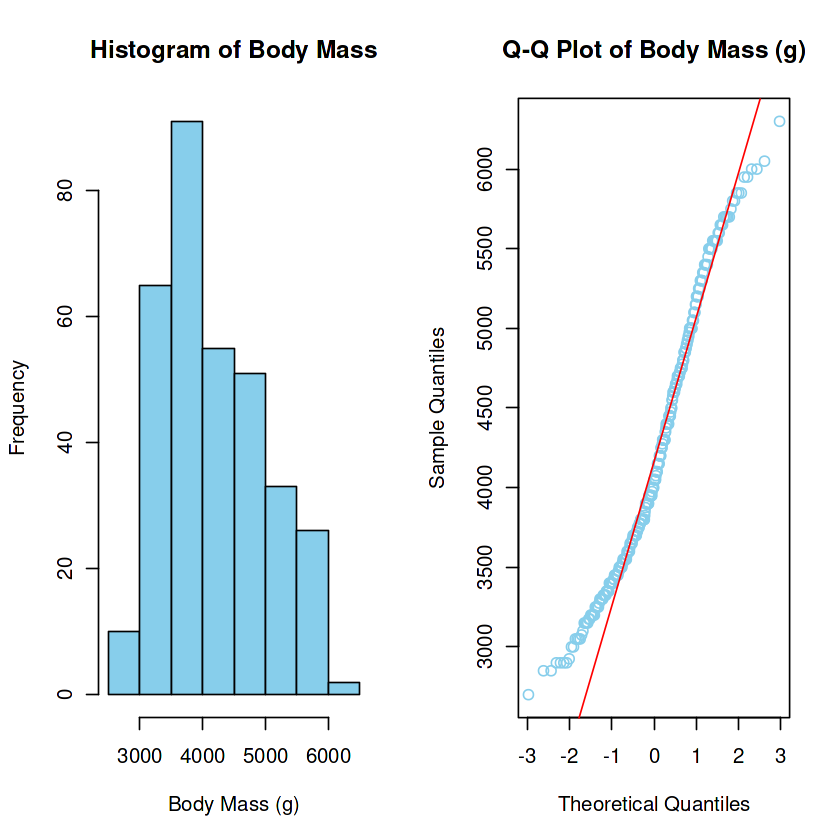

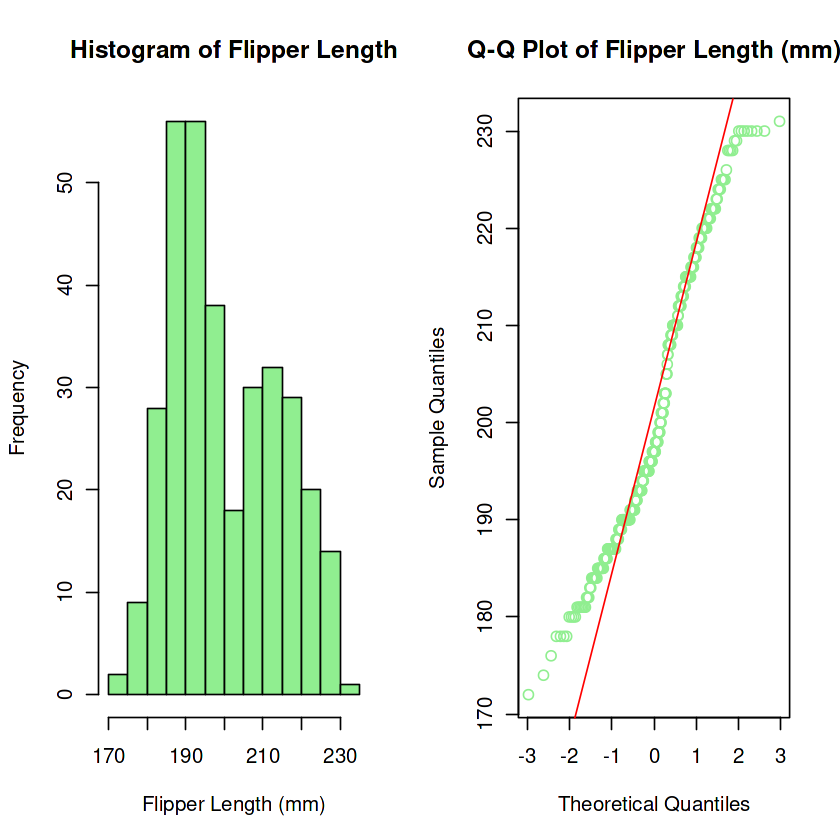

In [20]:
# This show two chart together. 1 row, 2 columns.
par(mfrow = c(1, 2))  

# Histograma 1: Body Mass
hist(penguins_clean$body_mass_g,
     col = "skyblue",
     main = "Histogram of Body Mass",
     xlab = "Body Mass (g)")

# Q-Q Plot 1: Body Mass
qqnorm(penguins_clean$body_mass_g,
       main = "Q-Q Plot of Body Mass (g)",
       col = "skyblue")
qqline(penguins_clean$body_mass_g, col = "red")



# Histograma 2: Flipper Length
hist(penguins_clean$flipper_length_mm,
     col = "lightgreen",
     main = "Histogram of Flipper Length",
     xlab = "Flipper Length (mm)")

# Q-Q Plot 2: Flipper Length
qqnorm(penguins_clean$flipper_length_mm,
       main = "Q-Q Plot of Flipper Length (mm)",
       col = "lightgreen")
qqline(penguins_clean$flipper_length_mm, col = "red")



**Observations:**
- The **histogram** charts show that both variables apper to be skewed to the right (right tail). Because of this, the data seems slightly deviate from  a normal distribution.
- The **Q-Q plots** show that, in both variables, the most of the data points follow the reference line, with clear deviation in the extremes. The graph illustrates a slightly "S" shape. Because of this, the data seems slightly deviate from  a normal distribution.

### Statistical normality assesment of Body mass and Flipper length: Shapiro-Wilk Test
- Since visual inspection showed a slight deviation of the variables from  a normal distribution, Shapiro test  was performed the confirm it statistically.  

In [21]:

# Shapiro-Wilk test for each variable
shapiro.test(penguins_clean$body_mass_g)

shapiro.test(penguins_clean$flipper_length_mm)


	Shapiro-Wilk normality test

data:  penguins_clean$body_mass_g
W = 0.95801, p-value = 3.568e-08



	Shapiro-Wilk normality test

data:  penguins_clean$flipper_length_mm
W = 0.95171, p-value = 5.393e-09


**Observations:**
- After running the Shapiro-Wilk test on body_mass_g and flipper_length_mm, both variables showed very small p-values (<0.05), indicating statistically significant deviations from a normal distribution. These results are consistent with the observations made using histograms and Q-Q plots. Because of this evidence of non-normality, the non-parametric Spearman’s rank correlation test will be used to assess the relationships between these variables.

## Testing correlation between body mass and flipper length: Spearman’s rank correlation test (non-parametric test).

In [22]:
cor.test(penguins_clean$body_mass_g, penguins_clean$flipper_length_mm, method = "spearman", exact = FALSE)


cor.test(penguins_clean$body_mass_g, penguins_clean$flipper_length_mm, method = "pearson", exact = FALSE)


	Spearman's rank correlation rho

data:  penguins_clean$body_mass_g and penguins_clean$flipper_length_mm
S = 982284, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.8403902 



	Pearson's product-moment correlation

data:  penguins_clean$body_mass_g and penguins_clean$flipper_length_mm
t = 32.562, df = 331, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8447622 0.8963550
sample estimates:
      cor 
0.8729789 


**Observations**:
- According to Spearman's rank correlation test, there is a very strong (rho = 0.84),  positive, and statistically significant (p-value < 2.2e-16) correlation between body mass and flipper length in the penguins. This indicates that as body mass of penguins increases, flipper length also tends to increase.
- Alternatively, since the normality assumption was violated but the sample is >100, I also applied Pearson's correlation test for comparison. Results were similarly strong, positive, and statistically significant(p-value < 2.2e-16).This support the conclusion that heavier penguins tend to have longer flippers. 

## Testing correlation between Body mass and flipper length by sex: Spearman’s rank correlation test.

In [23]:
# Subset: males
cor.test(
  ~ body_mass_g + flipper_length_mm,
  data = subset(penguins_clean, sex == "male"),
  method = "spearman"
)

# Subset: females
cor.test(
  ~ body_mass_g + flipper_length_mm,
  data = subset(penguins_clean, sex == "female"),
  method = "spearman"
)

Warning message in cor.test.default(x = mf[[1L]], y = mf[[2L]], ...):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  body_mass_g and flipper_length_mm
S = 160766, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.7965619 


Warning message in cor.test.default(x = mf[[1L]], y = mf[[2L]], ...):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  body_mass_g and flipper_length_mm
S = 156897, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.7904291 


**Observations**:
- For males, rho = 0.796, p-value < 2.2e-16
- For females, rho = 0.790, p-value < 2.2e-16
- These results shows that as body mass increases, flipper length also tends to increase in both sexes, and this relationship is statistically significant.



## Testing correlation between Body mass and flipper length by species: Spearman’s rank correlation test.

In [24]:
# For Adelie penguins
cor.test(
  ~ body_mass_g + flipper_length_mm,
  data = subset(penguins_clean, species == "Adelie"),
  method = "spearman"
)

# For Chinstrap penguins
cor.test(
  ~ body_mass_g + flipper_length_mm,
  data = subset(penguins_clean, species == "Chinstrap"),
  method = "spearman"
)

# For Gentoo penguins
cor.test(
  ~ body_mass_g + flipper_length_mm,
  data = subset(penguins_clean, species == "Gentoo"),
  method = "spearman"

)

Warning message in cor.test.default(x = mf[[1L]], y = mf[[2L]], ...):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  body_mass_g and flipper_length_mm
S = 272485, p-value = 1.426e-09
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.4746407 


Warning message in cor.test.default(x = mf[[1L]], y = mf[[2L]], ...):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  body_mass_g and flipper_length_mm
S = 17264, p-value = 3.983e-10
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.6704871 


Warning message in cor.test.default(x = mf[[1L]], y = mf[[2L]], ...):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  body_mass_g and flipper_length_mm
S = 76783, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.7265954 


**Observations**:
- After applying Spearman's rank correlation test to check relationship between body mass and flipper length within each species, the following results were found:
- Within Adelie, rho = 0.47, p-value = 1.426e-09, which indicate a moderate, positive and statistically significant relationship.
- Within Chinstrap, rho = 0.67, p-value = 3.983e-10, which indicates strong,positive and statistically significant relationship.
- Within Gentoo rho = 0.73, p-value < 2.2e-16, which indicates strong, positive and statistically significant relationship.
- Overall, heavier penguins tend to have longer flippers, however, the strength of this relationship varies by species.

# ✅ Conclusion

- After analyzing the Palmer Penguin dataset, it was found a srtong, positive and statistically significant relationship between body mass and flipper length across all species and sexes. Among the species, Gentoo penguins had the strongest association (rho = 0.73) while Adelie showed a moderate relationship (rho = 0.47).
- In conclusion, penguins with higher body mass tend to have longer flippers. This may happen to improve their swiming skills, which can help for hunting and surviving. 

# ✅ Skills Demonstrated in R:

- Data manipulation.
- Exploratory data analysis (EDA) and visualization of data.
- Detection of Outliers and normality assessment (histograms, Q-Q plots, Shapiro-Wilk test).
- Statistical testing, for example: correlation between variables.
- Clear communication through the document. 
- Organized and reproducible code documentation. 

# ✅ Data Source: 

- Dataset used in this project was accessed via the palmerpenguins R package.